# 02 - SARIMA: Modelo ARIMA com Componente Sazonal - SOLUTION

Este notebook contem a solucao completa do tutorial SARIMA, incluindo todos os exercicios resolvidos.

**Conteudo:**
- Teoria do modelo SARIMA
- Decomposicao sazonal
- Identificacao e ajuste de modelos SARIMA
- Comparacao com ARIMA puro
- **Exercicio 1 (SOLUCAO):** SARIMA no IPCA brasileiro
- **Exercicio 2 (SOLUCAO):** Efeito da transformacao log

## 1. Teoria do SARIMA

O modelo **SARIMA(p,d,q)(P,D,Q)[s]** estende o ARIMA para capturar padroes sazonais. A equacao geral e:

$$\Phi_P(L^s) \phi_p(L) (1-L)^d (1-L^s)^D y_t = c + \Theta_Q(L^s) \theta_q(L) \varepsilon_t$$

Onde:
- $\phi_p(L) = 1 - \phi_1 L - \cdots - \phi_p L^p$ : polinomio AR nao-sazonal
- $\Phi_P(L^s) = 1 - \Phi_1 L^s - \cdots - \Phi_P L^{Ps}$ : polinomio AR sazonal
- $\theta_q(L) = 1 + \theta_1 L + \cdots + \theta_q L^q$ : polinomio MA nao-sazonal
- $\Theta_Q(L^s) = 1 + \Theta_1 L^s + \cdots + \Theta_Q L^{Qs}$ : polinomio MA sazonal
- $(1-L)^d$ : diferenciacao regular de ordem $d$
- $(1-L^s)^D$ : diferenciacao sazonal de ordem $D$
- $s$ : periodo sazonal (ex: 12 para dados mensais)
- $\varepsilon_t \sim WN(0, \sigma^2)$

**Exemplo classico:** O modelo "airline" SARIMA(0,1,1)(0,1,1)[12] de Box & Jenkins.

## 2. Setup e Carregamento dos Dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

from chronobox import ARIMA, ClassicalDecomposition
from chronobox.tests_stat import adf_test, ljung_box_test
from chronobox.visualization import (
    plot_diagnostics, plot_forecast, plot_series, plot_decomposition, set_theme
)

set_theme('professional')
np.random.seed(42)

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('chronobox importado com sucesso!')

chronobox importado com sucesso!


In [2]:
airline = pd.read_csv(os.path.join(DATA_DIR, 'airline.csv'), parse_dates=['date'])
airline.set_index('date', inplace=True)
y = airline['passengers'].values
print(f'Periodo: {airline.index[0]} a {airline.index[-1]}')
print(f'Observacoes: {len(y)}')
print(f'Frequencia: mensal (s=12)')
airline.head()

Periodo: 1949-01-01 00:00:00 a 1960-12-01 00:00:00
Observacoes: 144
Frequencia: mensal (s=12)


,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


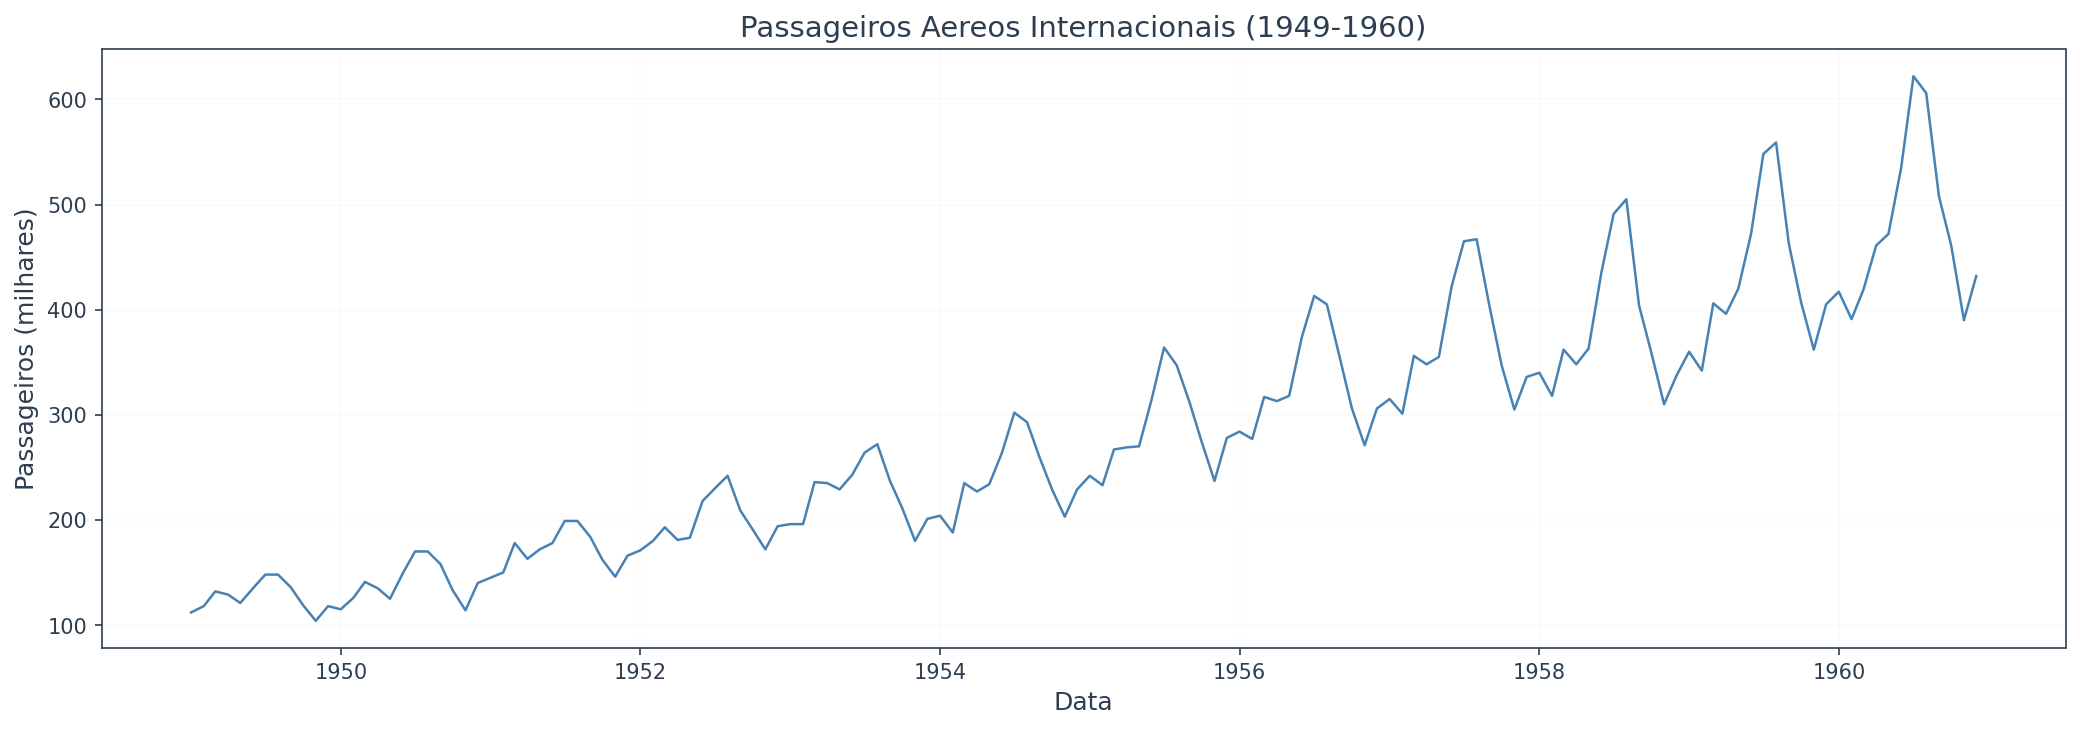

Observacoes:
- Tendencia crescente ao longo do periodo
- Sazonalidade clara com picos no verao (hemisferio norte)
- Amplitude sazonal cresce com o nivel da serie (sazonalidade multiplicativa)


In [3]:
# Visualizacao da serie airline
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(airline.index, y, color='steelblue', linewidth=1.2)
ax.set_title('Passageiros Aereos Internacionais (1949-1960)', fontsize=14)
ax.set_xlabel('Data')
ax.set_ylabel('Passageiros (milhares)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Observacoes:')
print('- Tendencia crescente ao longo do periodo')
print('- Sazonalidade clara com picos no verao (hemisferio norte)')
print('- Amplitude sazonal cresce com o nivel da serie (sazonalidade multiplicativa)')

## 3. Decomposicao Sazonal

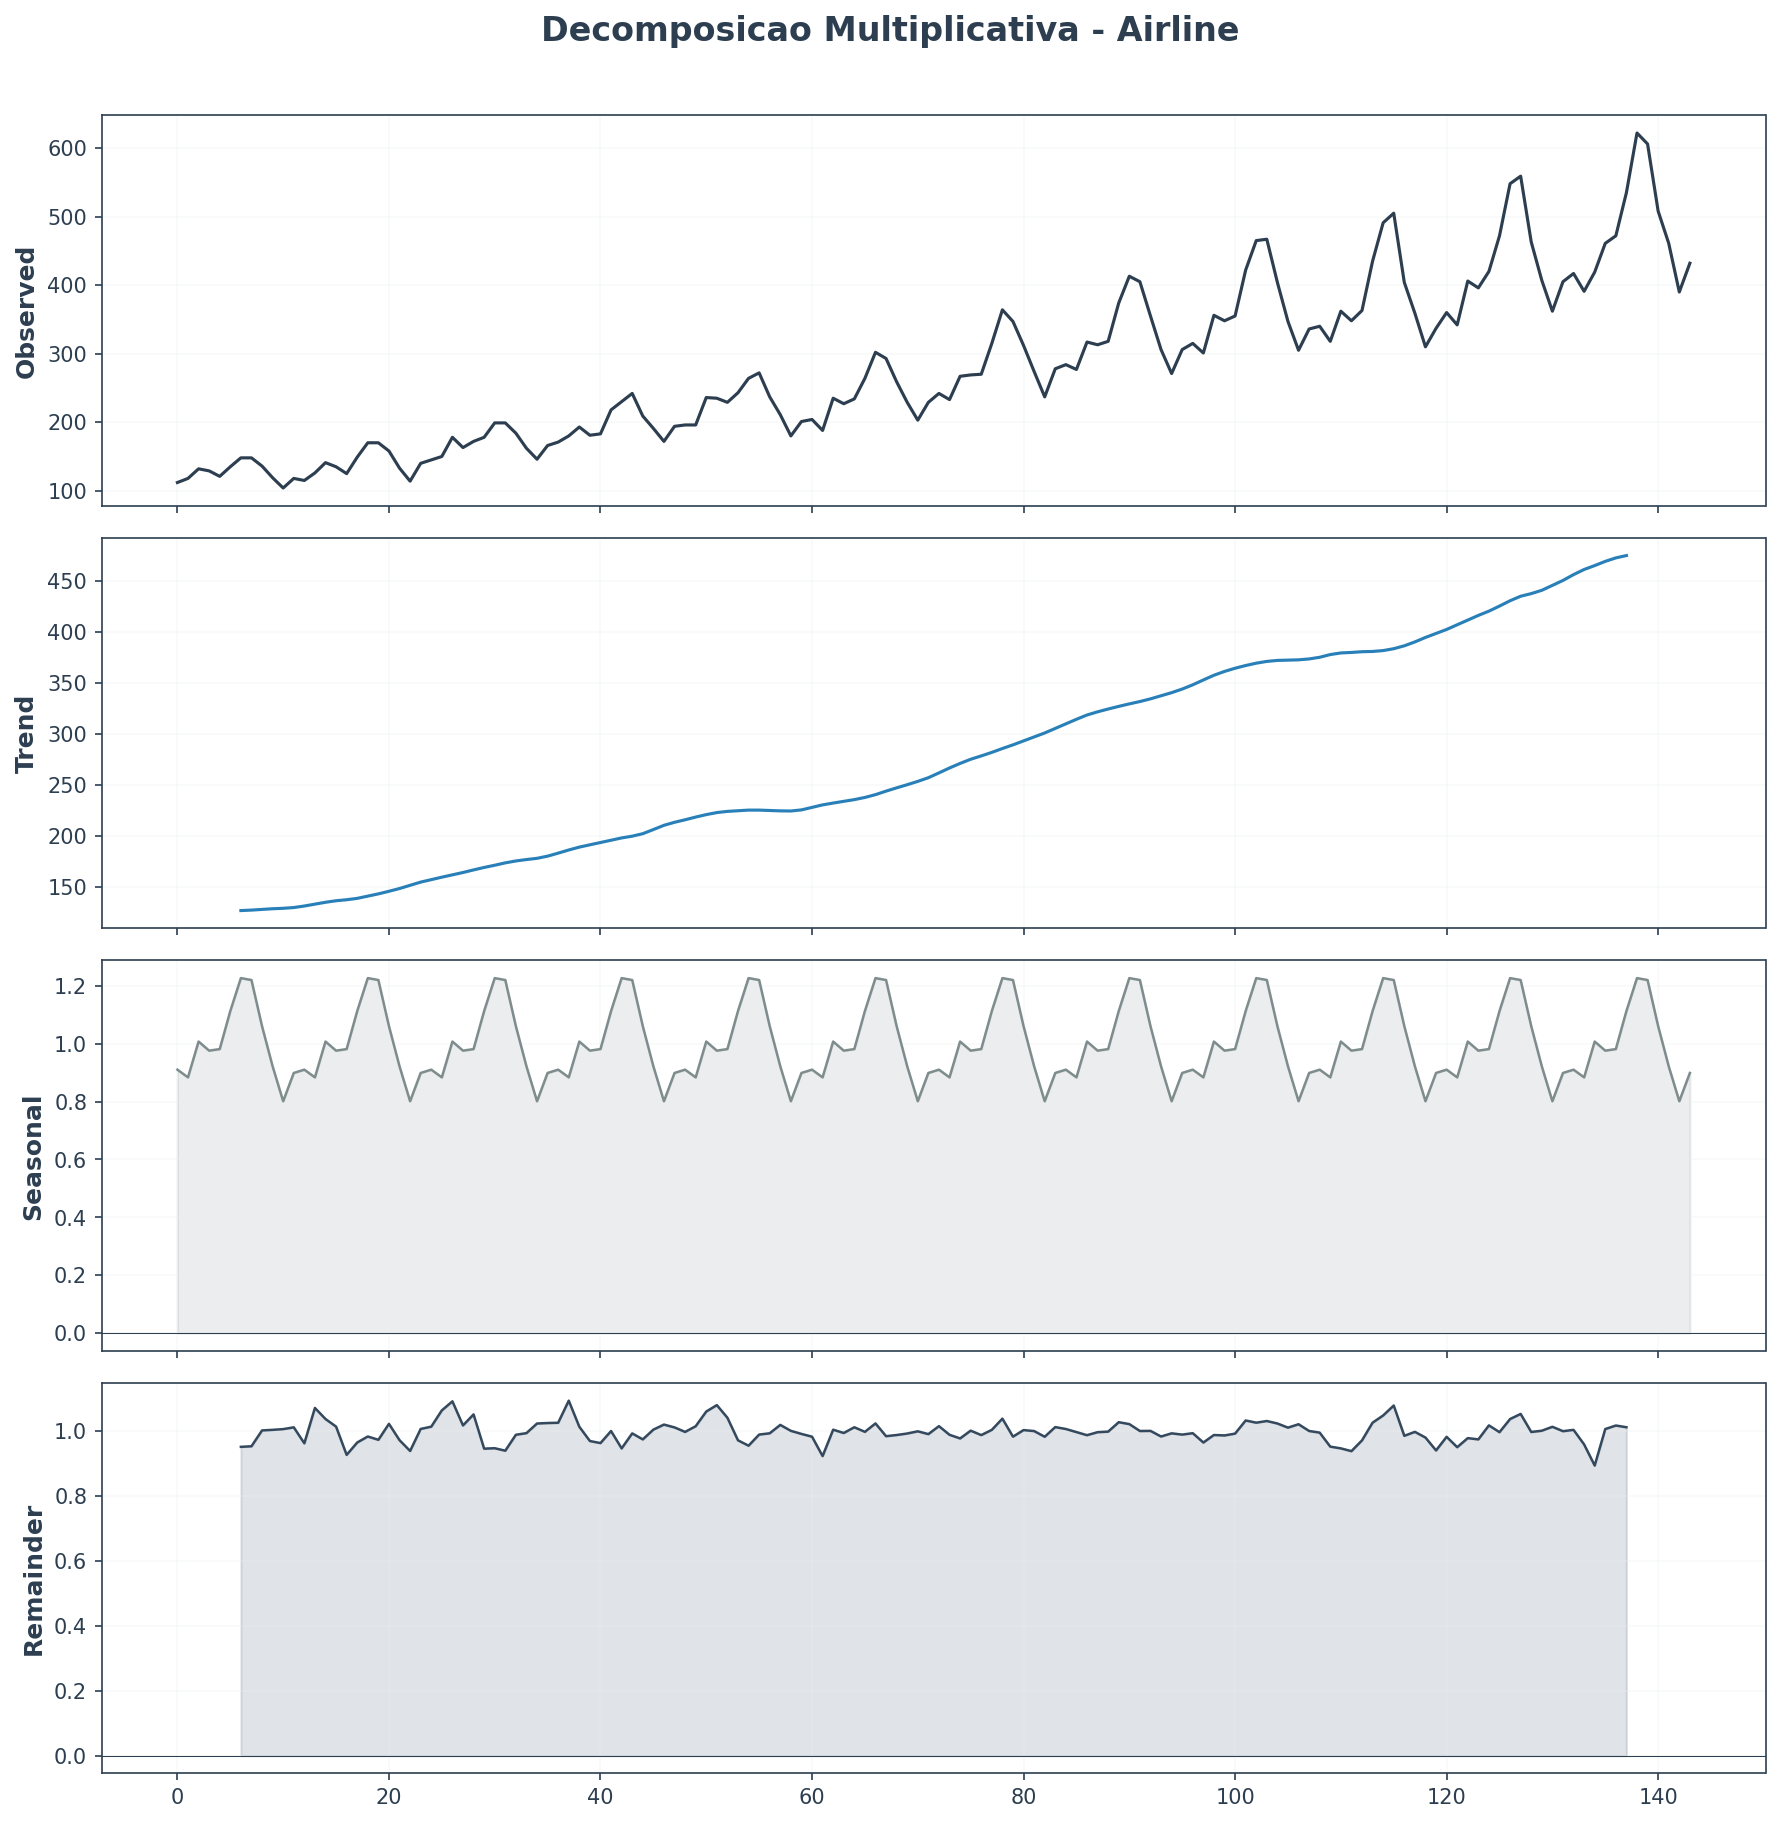

In [4]:
decomp = ClassicalDecomposition(period=12, model='multiplicative')
result_decomp = decomp.fit(y)
fig = plot_decomposition(result_decomp, title='Decomposicao Multiplicativa - Airline')
plt.show()

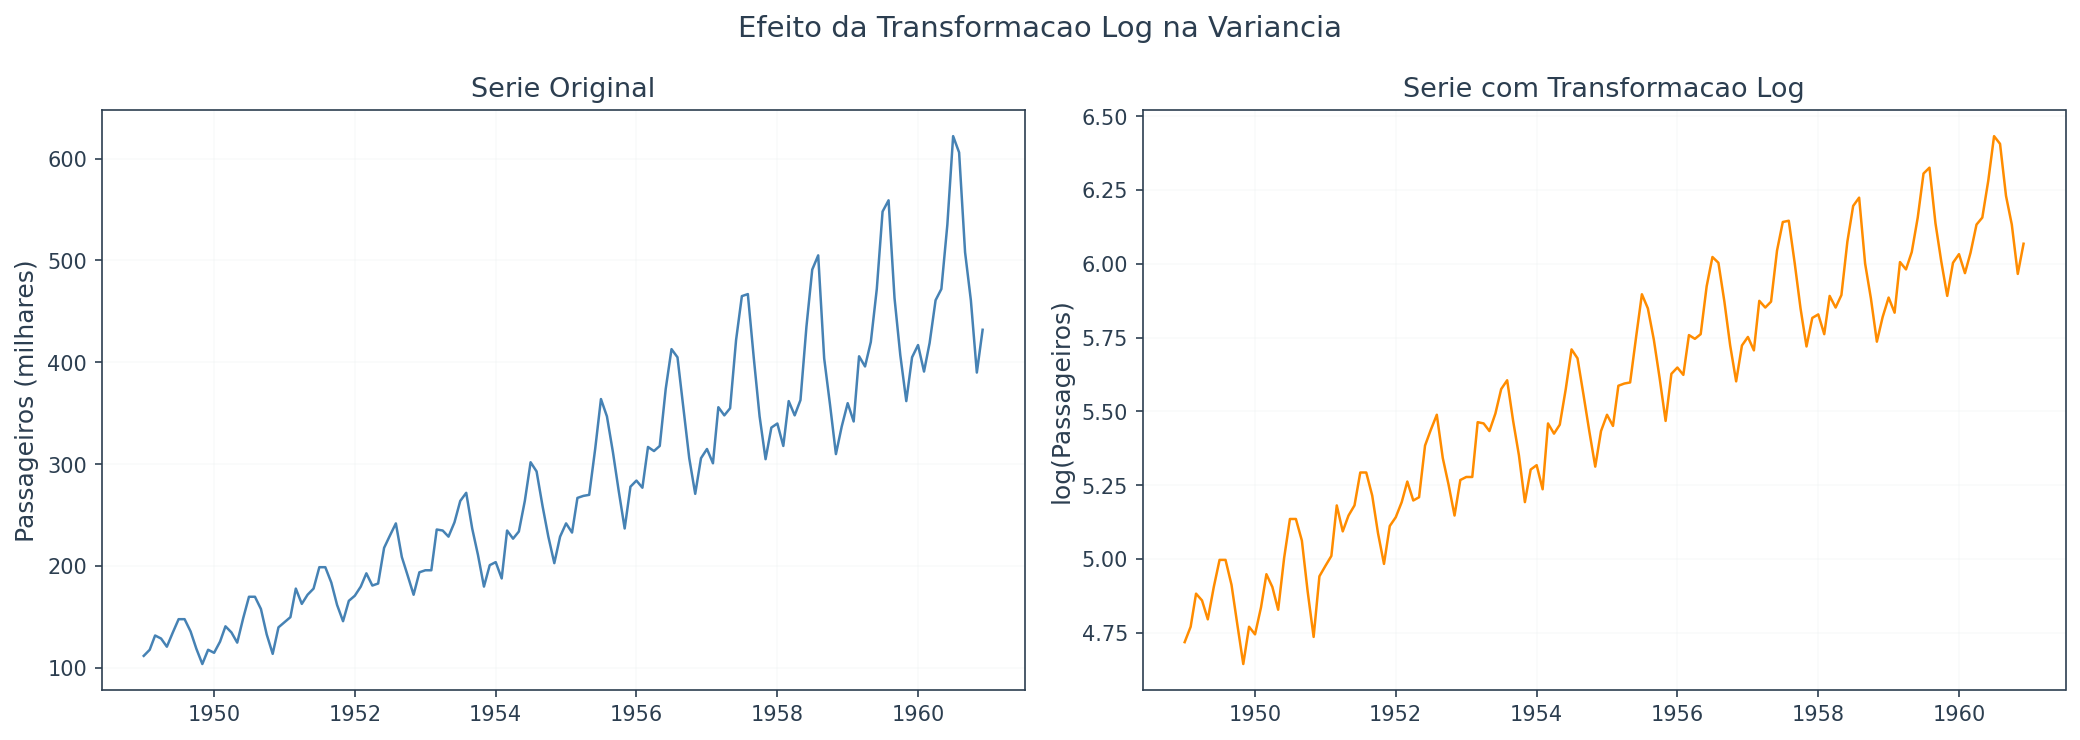

A transformacao log estabiliza a variancia, tornando a amplitude sazonal constante.


In [5]:
# Transformacao log para estabilizar variancia
y_log = np.log(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(airline.index, y, color='steelblue', linewidth=1.2)
axes[0].set_title('Serie Original', fontsize=13)
axes[0].set_ylabel('Passageiros (milhares)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(airline.index, y_log, color='darkorange', linewidth=1.2)
axes[1].set_title('Serie com Transformacao Log', fontsize=13)
axes[1].set_ylabel('log(Passageiros)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Efeito da Transformacao Log na Variancia', fontsize=14)
plt.tight_layout()
plt.show()

print('A transformacao log estabiliza a variancia, tornando a amplitude sazonal constante.')

## 4. Identificacao da Ordem do SARIMA

Para identificar a ordem do SARIMA, precisamos:

1. **Diferenciacao sazonal ($D$):** Aplicar $(1 - L^s)^D$ para remover o padrao sazonal
2. **Diferenciacao regular ($d$):** Aplicar $(1 - L)^d$ para remover a tendencia
3. **Verificar estacionariedade** com o teste ADF
4. **Analisar ACF/PACF** para determinar $p$, $q$, $P$, $Q$

In [6]:
y_log = np.log(y)
y_sdiff = y_log[12:] - y_log[:-12]  # D=1
y_ddiff = np.diff(y_sdiff)  # d=1

adf_sdiff = adf_test(y_sdiff)
adf_ddiff = adf_test(y_ddiff)
print(f'Apos D=1: ADF p-valor = {adf_sdiff.pvalue:.4f}')
print(f'Apos D=1, d=1: ADF p-valor = {adf_ddiff.pvalue:.4f}')

Apos D=1: ADF p-valor = 0.0788
Apos D=1, d=1: ADF p-valor = 0.0050


## 5. Ajuste SARIMA com chronobox

In [7]:
sarima = ARIMA(order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
res_sarima = sarima.fit(y_log)
print(res_sarima.summary())

                    Model: ARIMA(0,1,1)(0,1,1)[12]                    
  Nobs: 144    Effective Nobs: 131
  Log-Likelihood: 244.6965
  AIC: -483.3930    BIC: -474.7674    AICc: -483.2040    HQIC: -479.8880
----------------------------------------------------------------------
  Parameter         Estimate    Std.Err    t-value    p-value
----------------------------------------------------------------------
  ma.L1              -0.4018     0.0896    -4.4824     0.0000
  ma.S.L12           -0.5569     0.0731    -7.6182     0.0000
  sigma2              0.0013     0.0002     8.0640     0.0000
  Residual std: 0.0374    Mean: 0.0020
  Ljung-Box(lag=10): stat=7.7522  p-value=0.6530


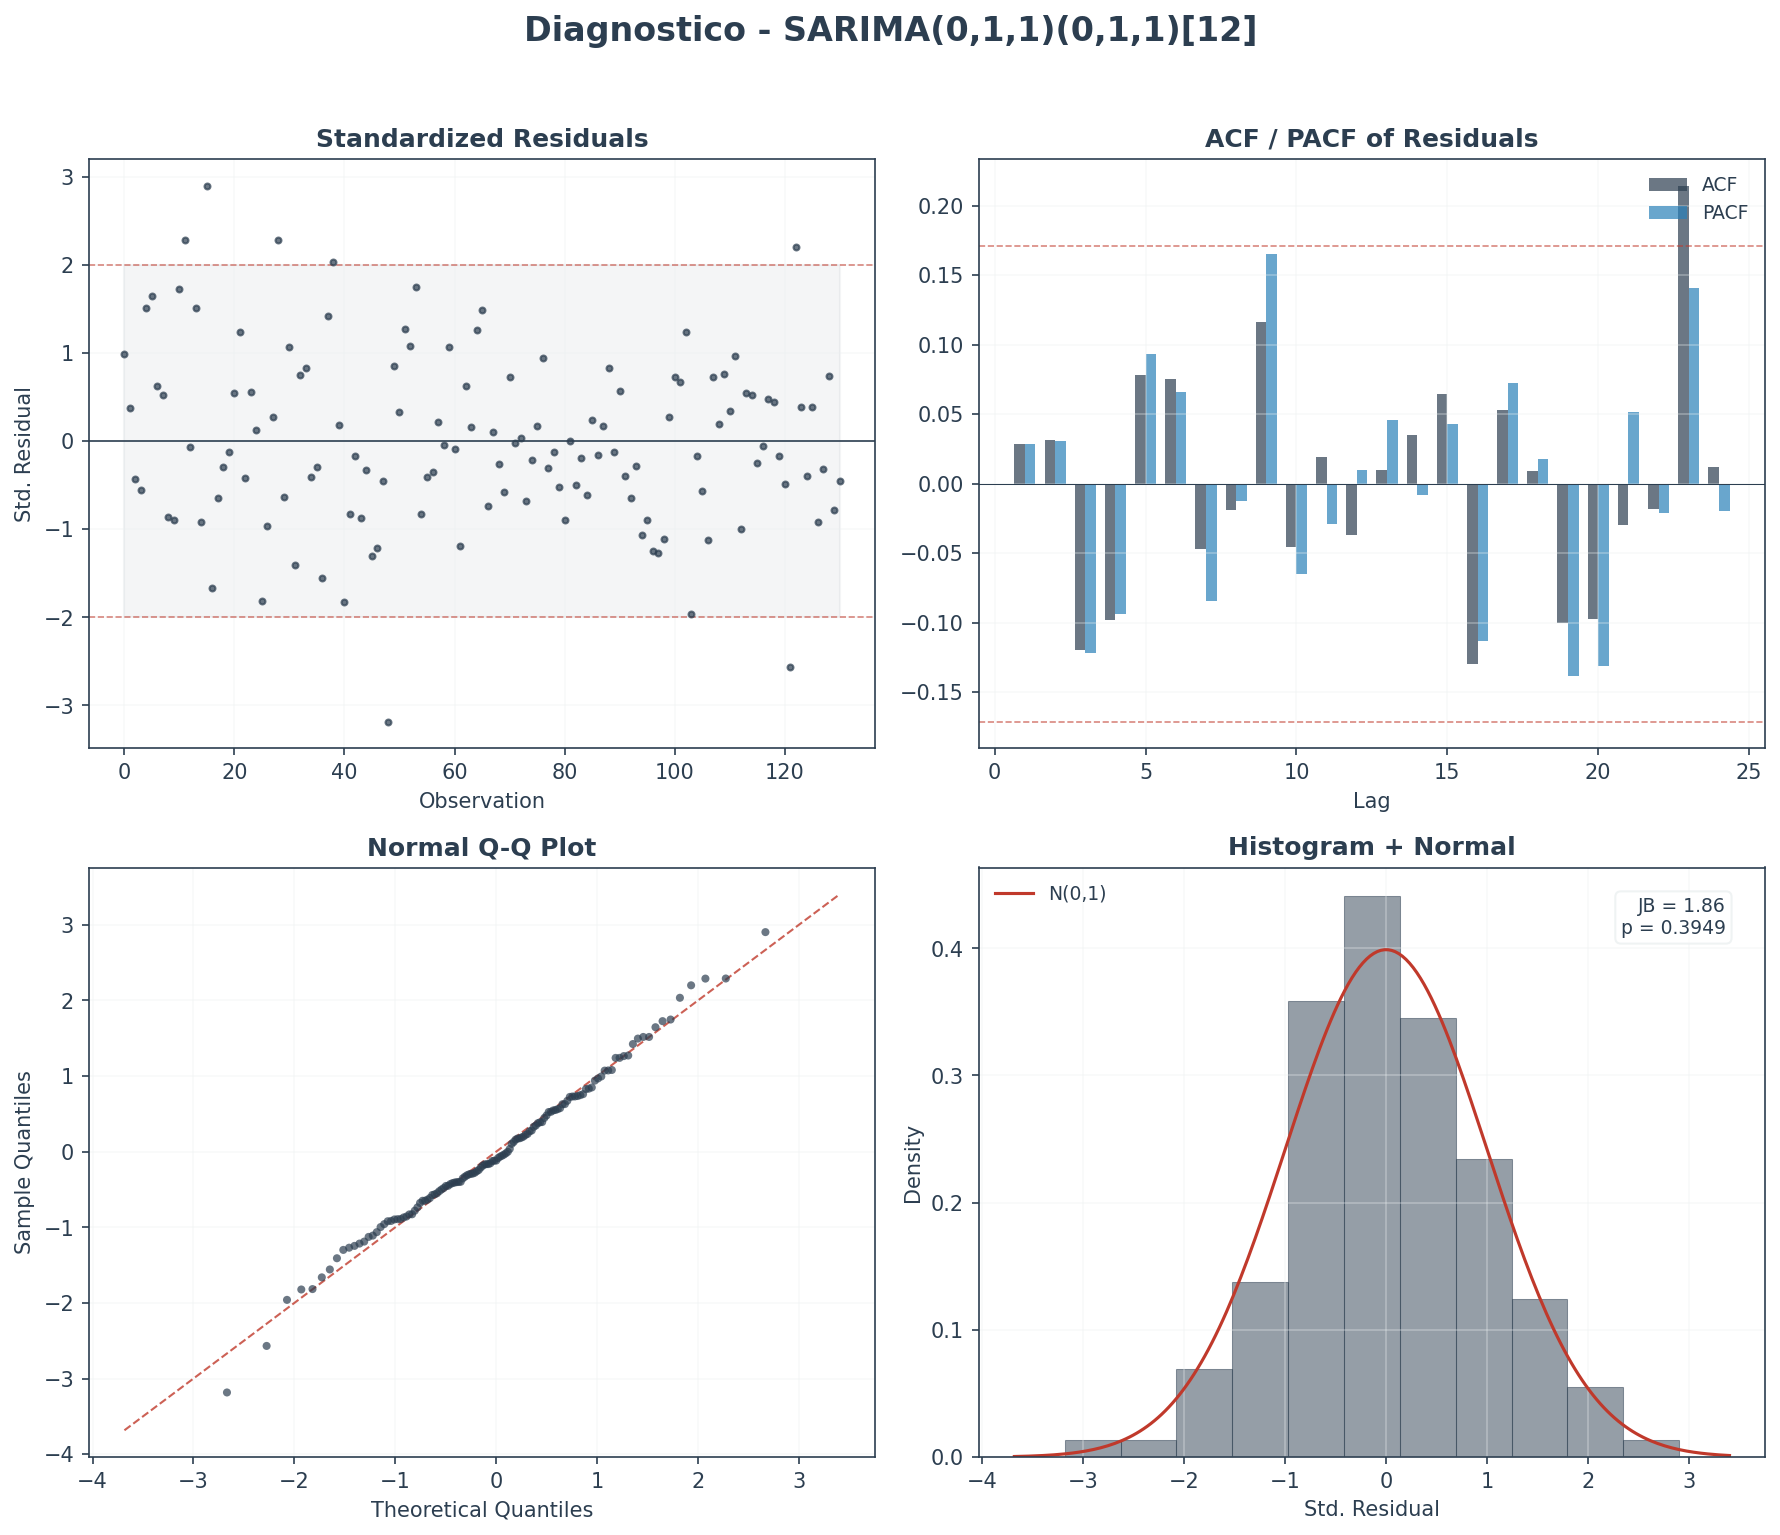

In [8]:
# Diagnostico do modelo SARIMA(0,1,1)(0,1,1)[12]
fig = plot_diagnostics(res_sarima, lags=24, title='Diagnostico - SARIMA(0,1,1)(0,1,1)[12]')
plt.show()

In [9]:
# Teste de Ljung-Box nos residuos em diferentes lags
print('Teste de Ljung-Box nos residuos do SARIMA(0,1,1)(0,1,1)[12]:')
print(f'{"Lag":<10} {"Estatistica":<15} {"p-valor":<15} {"Conclusao"}')
print('-' * 55)
for lag in [12, 24, 36]:
    lb = ljung_box_test(res_sarima.residuals, lags=lag, model_df=2)
    conclusao = 'Adequado (p>0.05)' if lb.pvalue > 0.05 else 'Correlacao residual (p<0.05)'
    print(f'{lag:<10} {lb.statistic:<15.4f} {lb.pvalue:<15.4f} {conclusao}')

Teste de Ljung-Box nos residuos do SARIMA(0,1,1)(0,1,1)[12]:
Lag        Estatistica     p-valor         Conclusao
-------------------------------------------------------
12         8.0064          0.6282          Adequado (p>0.05)
24         22.4880         0.4311          Adequado (p>0.05)
36         32.2619         0.5530          Adequado (p>0.05)


## 6. Comparacao: com vs sem Componente Sazonal

In [10]:
# Comparacao de varios modelos
modelos = {
    'ARIMA(1,1,1)': ((1,1,1), None),
    'SARIMA(0,1,1)(0,1,1)[12]': ((0,1,1), (0,1,1,12)),
    'SARIMA(1,1,0)(0,1,1)[12]': ((1,1,0), (0,1,1,12)),
    'SARIMA(1,1,1)(0,1,1)[12]': ((1,1,1), (0,1,1,12)),
}

resultados = {}
print(f'{"Modelo":<35} {"AIC":>10} {"BIC":>10}')
print('-' * 57)

for nome, (order, seasonal) in modelos.items():
    try:
        if seasonal is not None:
            m = ARIMA(order=order, seasonal_order=seasonal)
        else:
            m = ARIMA(order=order)
        r = m.fit(y_log)
        resultados[nome] = r
        print(f'{nome:<35} {r.aic:>10.2f} {r.bic:>10.2f}')
    except Exception as e:
        print(f'{nome:<35} FALHA: {e}')

melhor = min(resultados, key=lambda k: resultados[k].aic)
print(f'\nMelhor modelo por AIC: {melhor}')

Modelo                                     AIC        BIC
---------------------------------------------------------
ARIMA(1,1,1)                           -238.60    -229.72


SARIMA(0,1,1)(0,1,1)[12]               -483.39    -474.77


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


SARIMA(1,1,0)(0,1,1)[12]               -481.48    -472.86


SARIMA(1,1,1)(0,1,1)[12]               -481.89    -470.39

Melhor modelo por AIC: SARIMA(0,1,1)(0,1,1)[12]


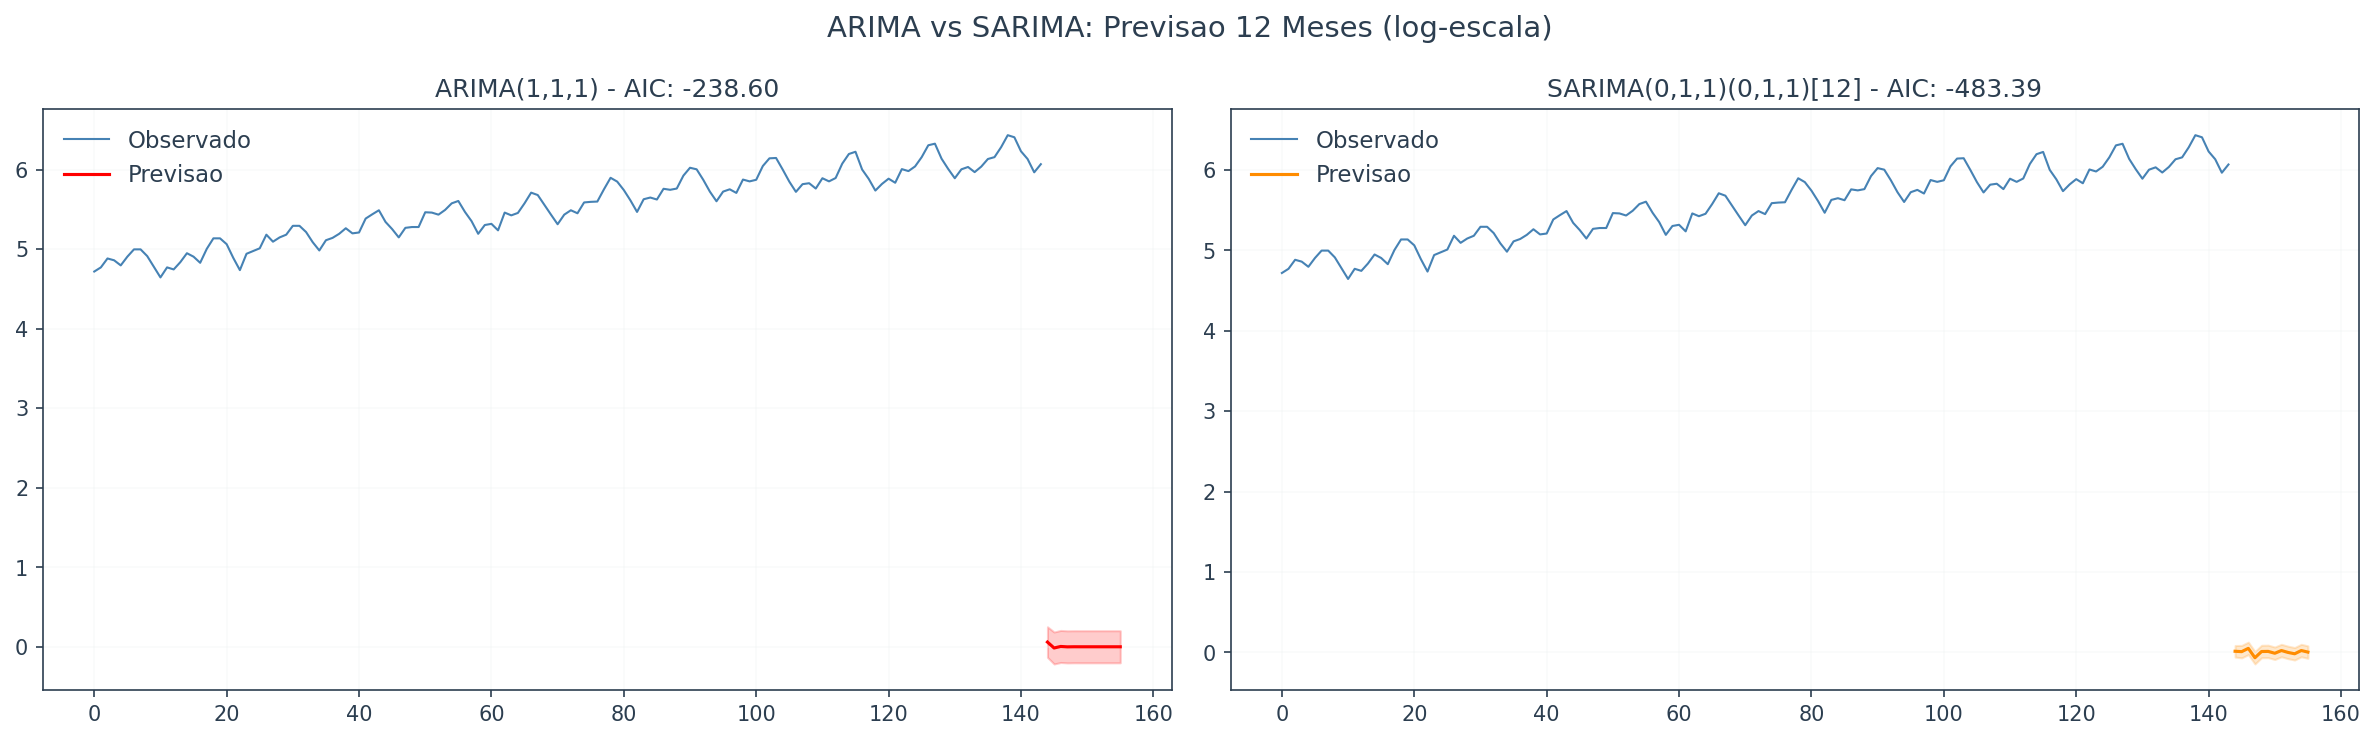

O SARIMA captura o padrao sazonal na previsao, enquanto o ARIMA puro nao.


In [11]:
# Comparacao visual: ARIMA vs SARIMA (previsao 12 meses)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ARIMA(1,1,1) - sem sazonalidade
if 'ARIMA(1,1,1)' in resultados:
    res_arima = resultados['ARIMA(1,1,1)']
    fc_arima = res_arima.forecast(steps=12, alpha=0.05)
    axes[0].plot(y_log, color='steelblue', linewidth=1.0, label='Observado')
    x_fc = np.arange(len(y_log), len(y_log) + 12)
    axes[0].plot(x_fc, fc_arima['forecast'], color='red', linewidth=1.5, label='Previsao')
    axes[0].fill_between(x_fc, fc_arima['lower'], fc_arima['upper'], alpha=0.2, color='red')
    axes[0].set_title(f'ARIMA(1,1,1) - AIC: {res_arima.aic:.2f}', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# SARIMA(0,1,1)(0,1,1)[12]
fc_sarima = res_sarima.forecast(steps=12, alpha=0.05)
axes[1].plot(y_log, color='steelblue', linewidth=1.0, label='Observado')
x_fc = np.arange(len(y_log), len(y_log) + 12)
axes[1].plot(x_fc, fc_sarima['forecast'], color='darkorange', linewidth=1.5, label='Previsao')
axes[1].fill_between(x_fc, fc_sarima['lower'], fc_sarima['upper'], alpha=0.2, color='darkorange')
axes[1].set_title(f'SARIMA(0,1,1)(0,1,1)[12] - AIC: {res_sarima.aic:.2f}', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ARIMA vs SARIMA: Previsao 12 Meses (log-escala)', fontsize=14)
plt.tight_layout()
plt.show()

print('O SARIMA captura o padrao sazonal na previsao, enquanto o ARIMA puro nao.')

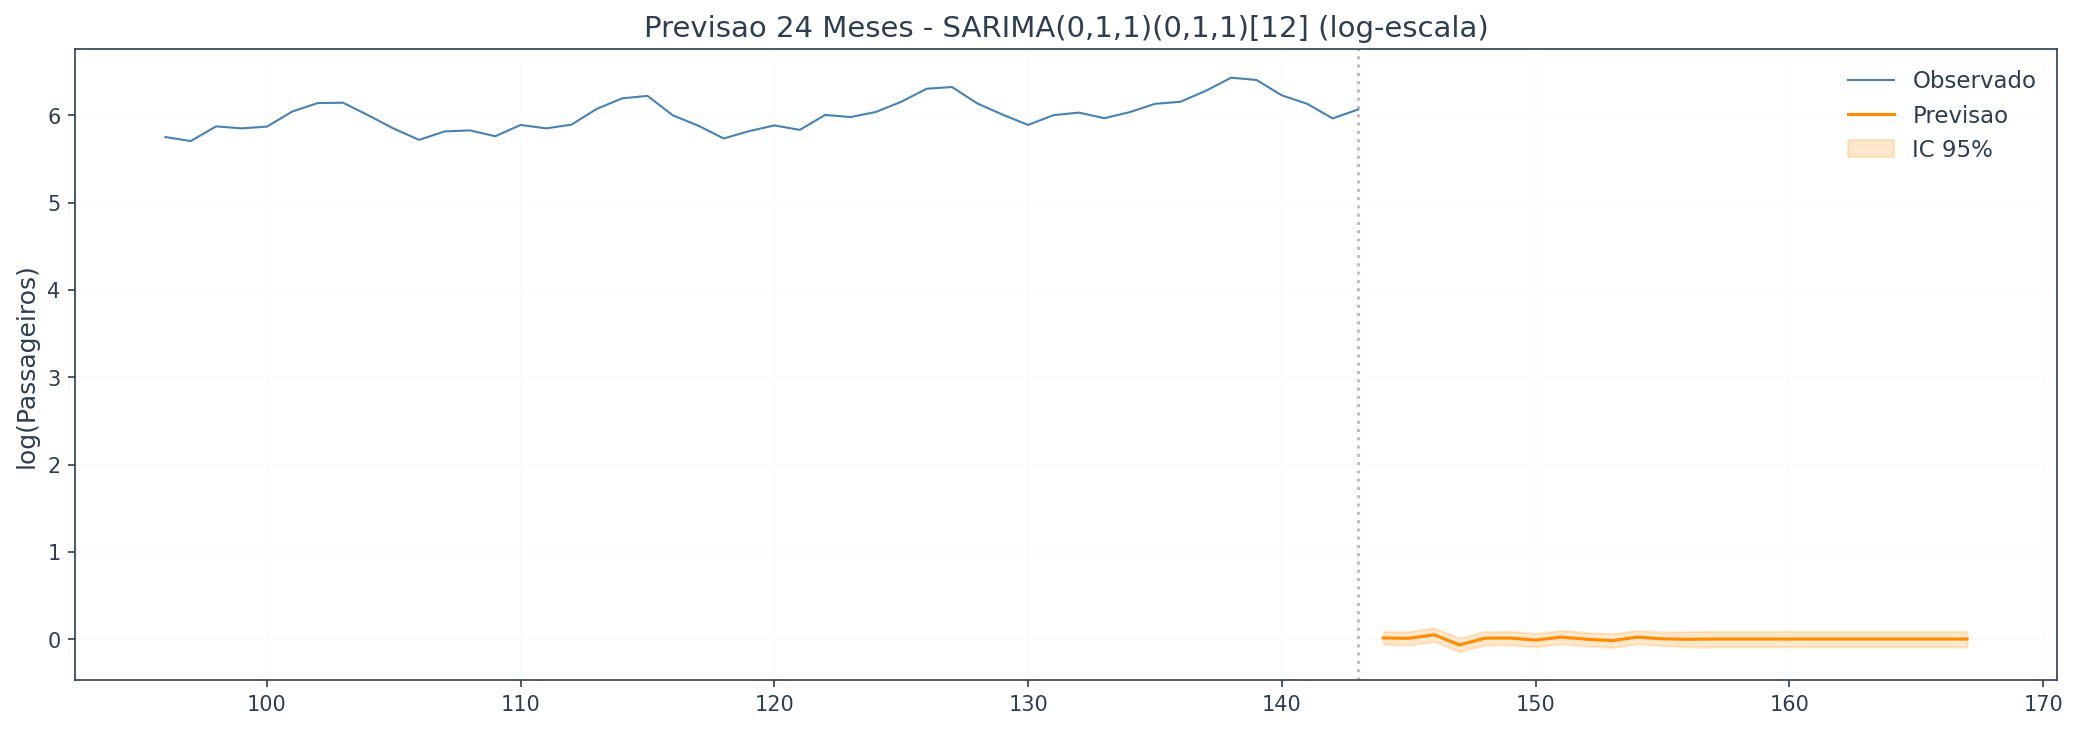

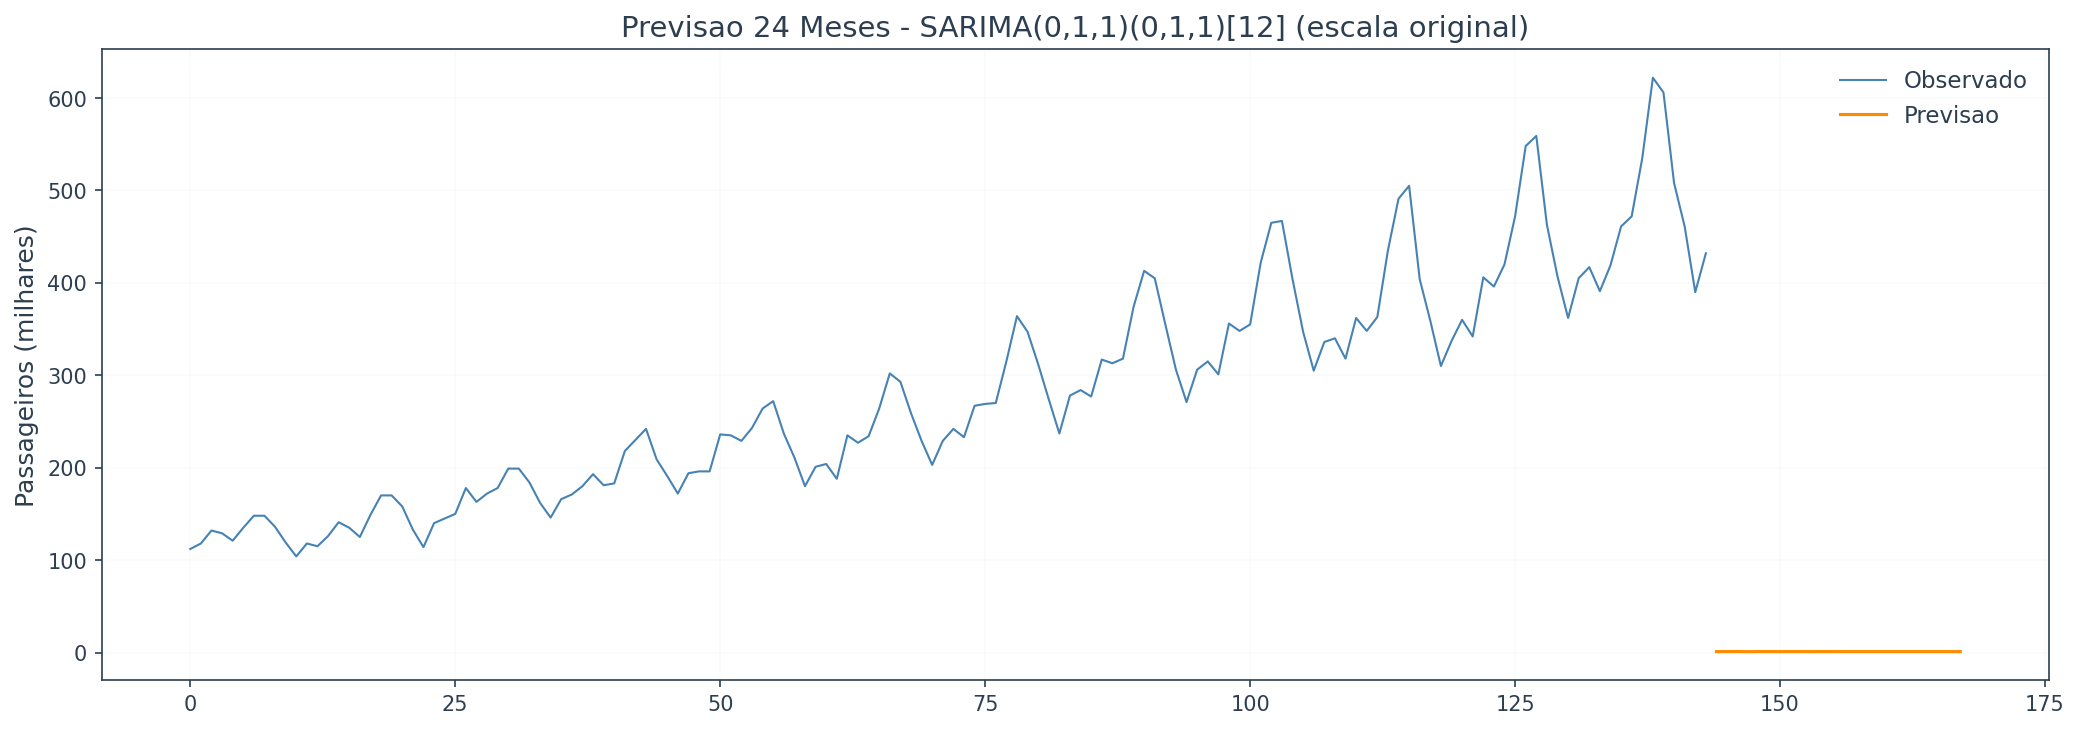

In [12]:
# Previsao de 24 meses com o melhor SARIMA
res_best = resultados[melhor]
fc_24 = res_best.forecast(steps=24, alpha=0.05)

# Previsao na log-escala
fig, ax = plt.subplots(figsize=(14, 5))
n_show = 48
ax.plot(range(len(y_log)-n_show, len(y_log)), y_log[-n_show:], color='steelblue', linewidth=1.0, label='Observado')
x_fc = np.arange(len(y_log), len(y_log) + 24)
ax.plot(x_fc, fc_24['forecast'], color='darkorange', linewidth=1.5, label='Previsao')
ax.fill_between(x_fc, fc_24['lower'], fc_24['upper'], alpha=0.2, color='darkorange', label='IC 95%')
ax.axvline(len(y_log)-1, color='gray', linestyle=':', alpha=0.5)
ax.set_title(f'Previsao 24 Meses - {melhor} (log-escala)', fontsize=14)
ax.set_ylabel('log(Passageiros)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Previsao na escala original
fc_original = np.exp(fc_24['forecast'])
lower_original = np.exp(fc_24['lower'])
upper_original = np.exp(fc_24['upper'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y, color='steelblue', linewidth=1.0, label='Observado')
x_fc = np.arange(len(y), len(y) + 24)
ax.plot(x_fc, fc_original, color='darkorange', linewidth=1.5, label='Previsao')
ax.fill_between(x_fc, lower_original, upper_original, alpha=0.2, color='darkorange')
ax.set_title(f'Previsao 24 Meses - {melhor} (escala original)', fontsize=14)
ax.set_ylabel('Passageiros (milhares)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercicio 1: Ajustar SARIMA no brazil_ipca.csv - SOLUCAO

**Objetivo:** Aplicar o modelo SARIMA ao indice IPCA (inflacao brasileira).

Passos:
1. Carregar e visualizar os dados
2. Realizar decomposicao sazonal
3. Identificar ordem via ACF/PACF
4. Ajustar pelo menos 3 modelos SARIMA
5. Diagnosticar o melhor modelo
6. Gerar previsao de 12 meses

Periodo: 2004-01-01 00:00:00 a 2023-12-01 00:00:00
Observacoes: 240


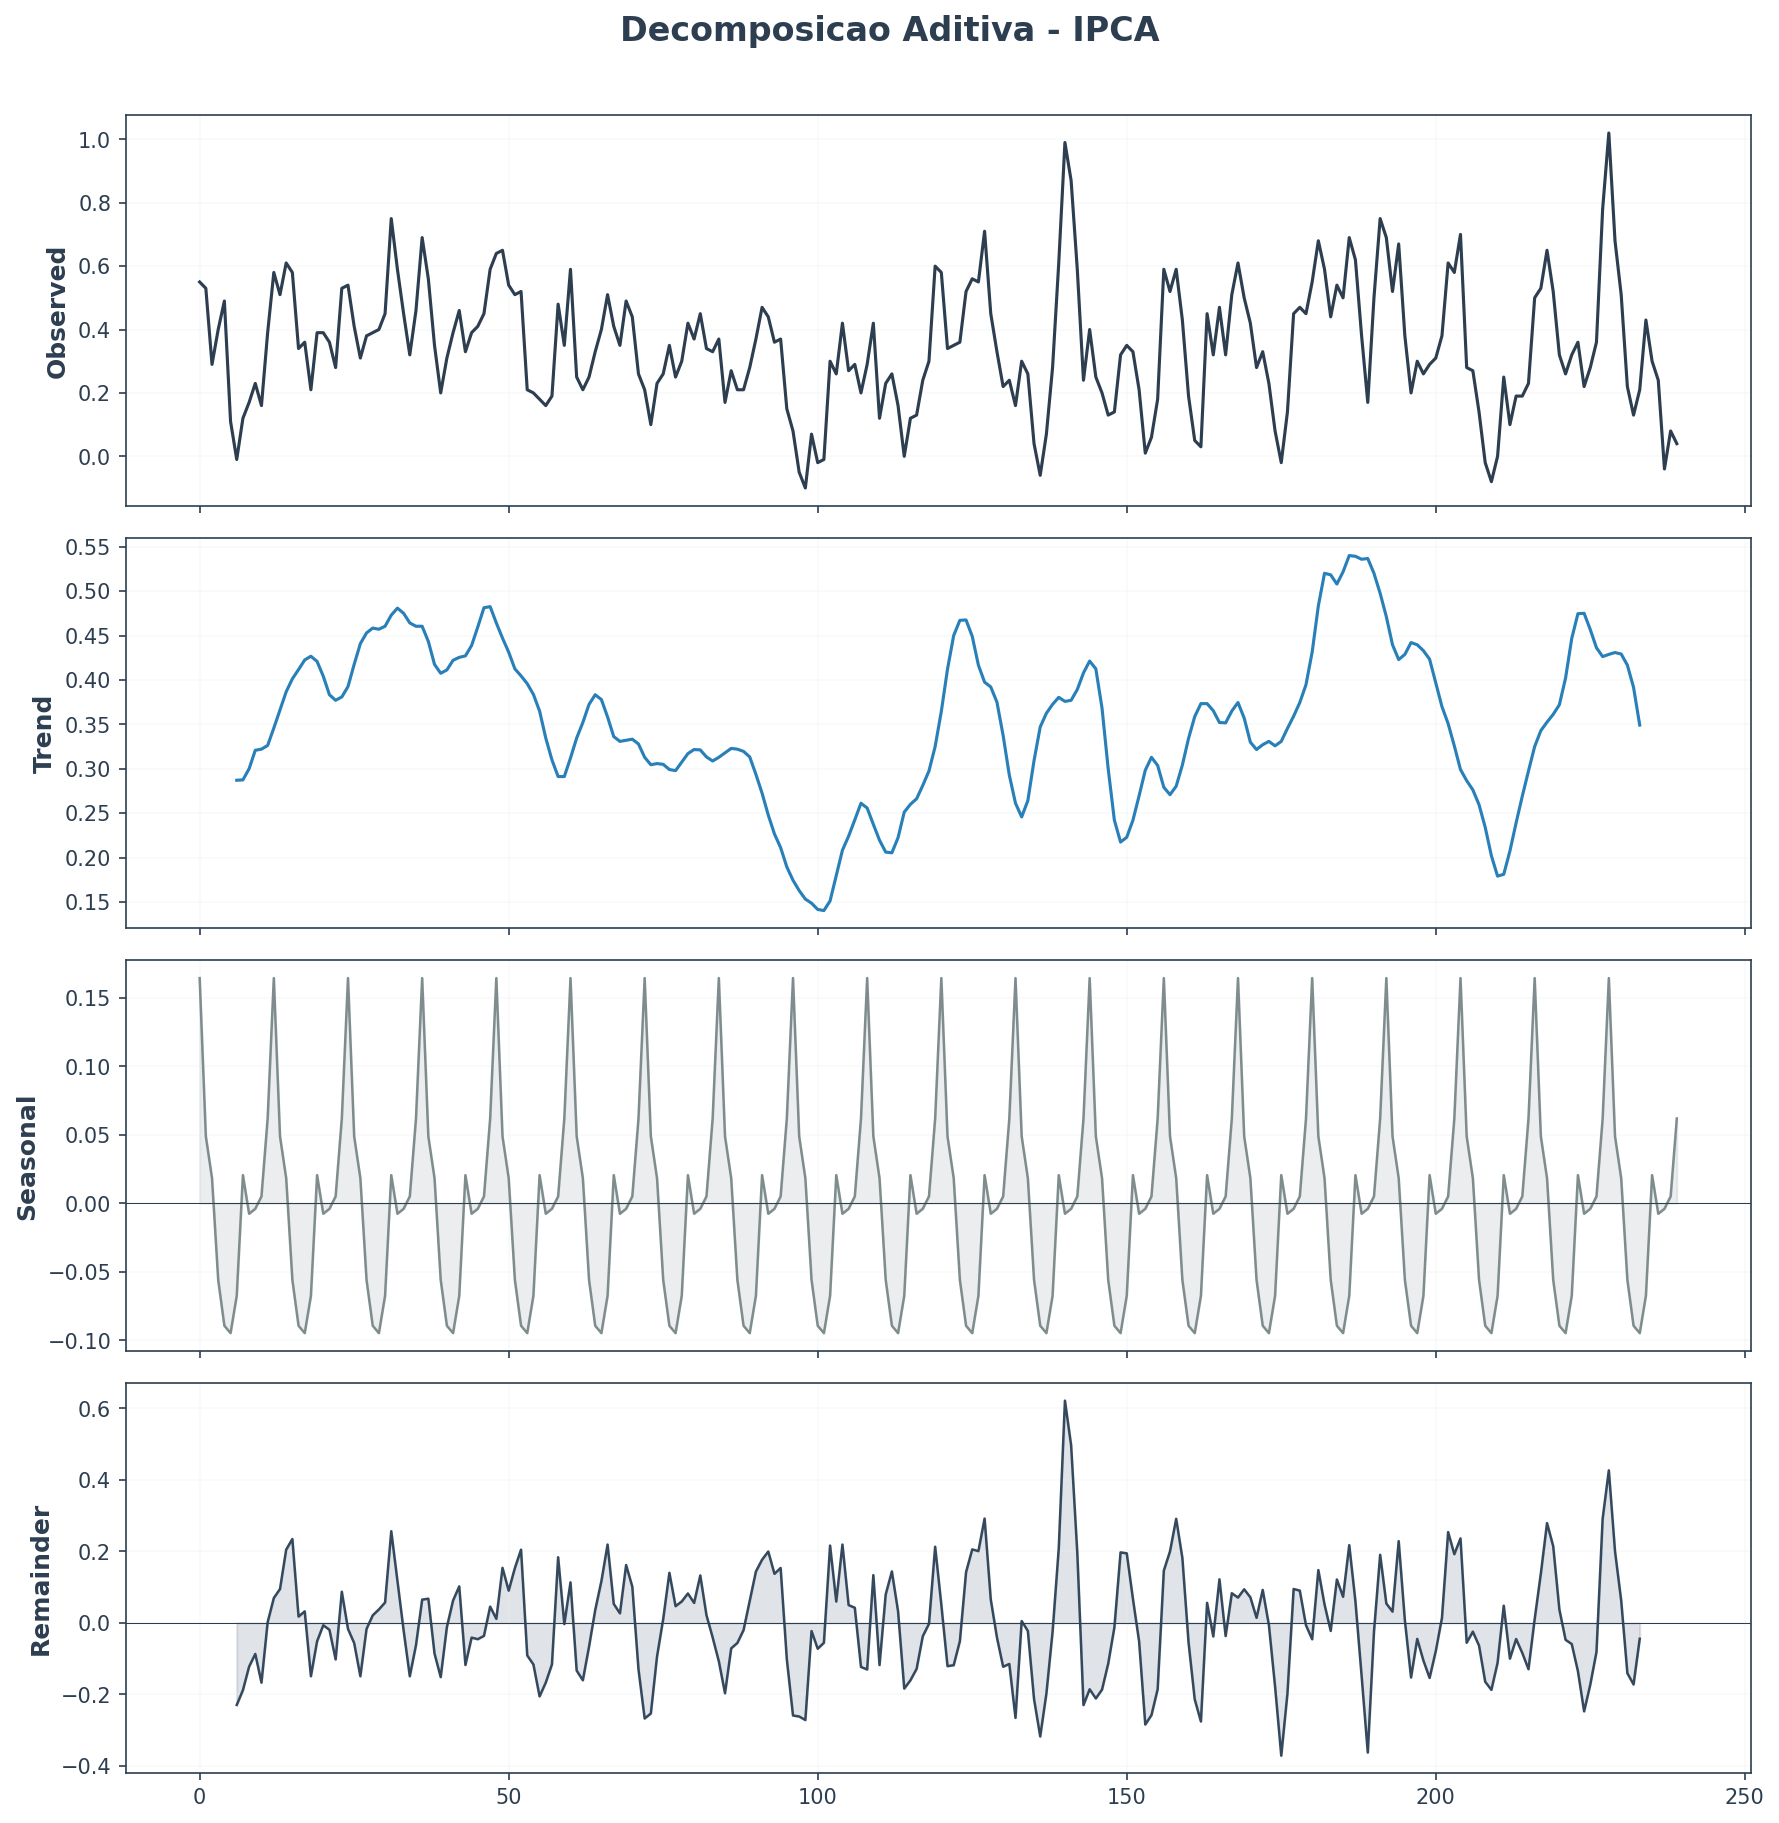

IPCA usa decomposicao aditiva pois a amplitude sazonal e relativamente constante.


In [13]:
# Exercicio 1 - SOLUCAO COMPLETA
# 1. Carregar IPCA
ipca = pd.read_csv(os.path.join(DATA_DIR, 'brazil_ipca.csv'), parse_dates=['date'])
ipca.set_index('date', inplace=True)
y_ipca = ipca['ipca'].values

print(f'Periodo: {ipca.index[0]} a {ipca.index[-1]}')
print(f'Observacoes: {len(y_ipca)}')

# 2. Decomposicao sazonal - aditiva (IPCA pode ter valores negativos)
decomp_ipca = ClassicalDecomposition(period=12, model='additive')
result_ipca = decomp_ipca.fit(y_ipca)
fig = plot_decomposition(result_ipca, title='Decomposicao Aditiva - IPCA')
plt.show()

print('IPCA usa decomposicao aditiva pois a amplitude sazonal e relativamente constante.')

ADF apos D=1, d=1: stat=-7.4678, p=0.0050


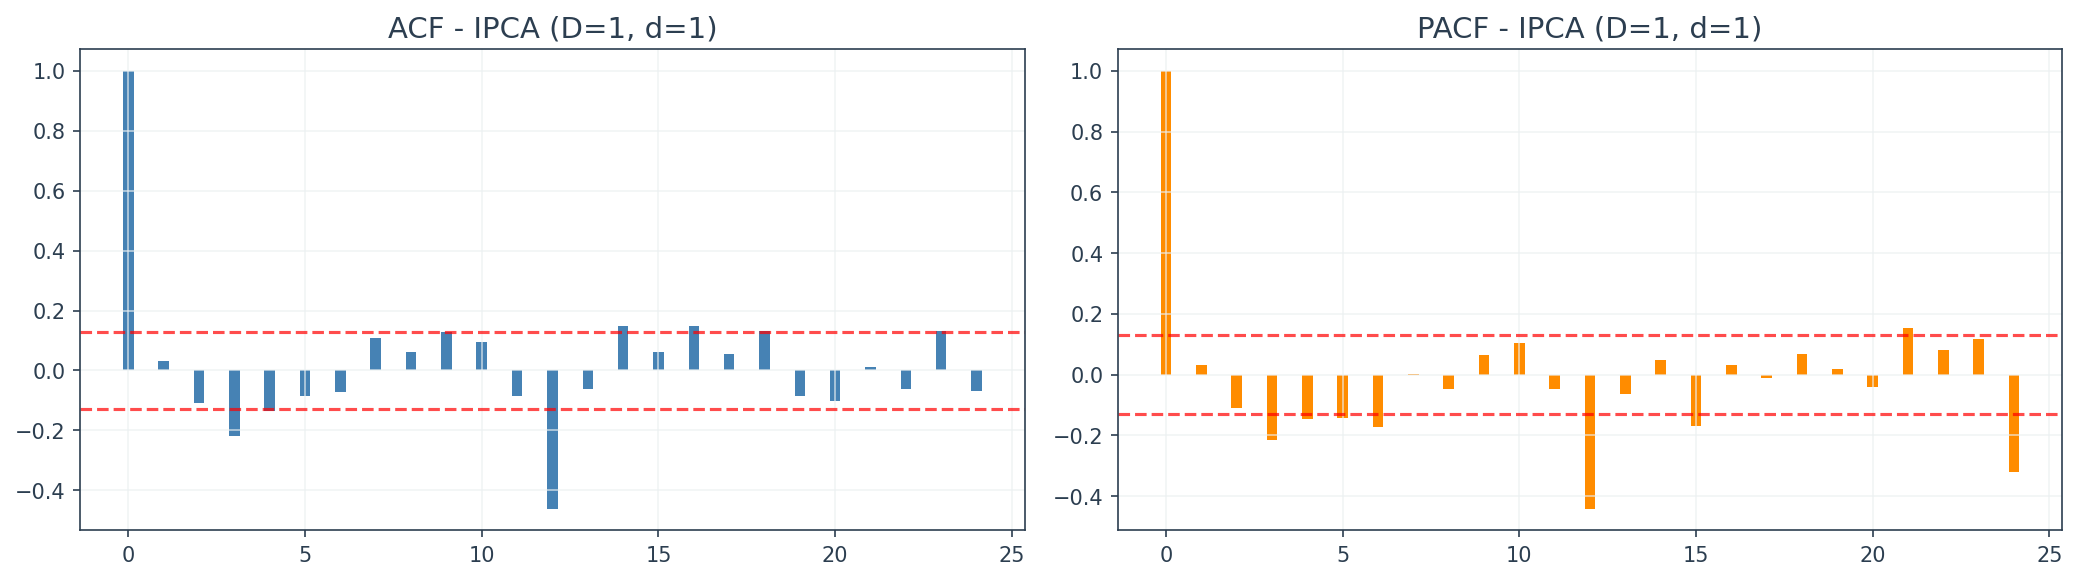

In [14]:
# 3. Identificacao via ACF/PACF
from chronobox.visualization.diagnostics_plot import _compute_acf, _compute_pacf

# Diferenciacao sazonal + regular
y_ipca_sdiff = y_ipca[12:] - y_ipca[:-12]
y_ipca_ddiff = np.diff(y_ipca_sdiff)

adf_ipca = adf_test(y_ipca_ddiff)
print(f'ADF apos D=1, d=1: stat={adf_ipca.statistic:.4f}, p={adf_ipca.pvalue:.4f}')

max_lag = 24
acf_vals = _compute_acf(y_ipca_ddiff, max_lag)
pacf_vals = _compute_pacf(y_ipca_ddiff, max_lag)
ci = 1.96 / np.sqrt(len(y_ipca_ddiff))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(max_lag + 1), acf_vals, width=0.3, color='steelblue')
axes[0].axhline(ci, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(-ci, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('ACF - IPCA (D=1, d=1)')

axes[1].bar(range(max_lag + 1), pacf_vals, width=0.3, color='darkorange')
axes[1].axhline(ci, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(-ci, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('PACF - IPCA (D=1, d=1)')

plt.tight_layout()
plt.show()

In [15]:
# 4. Ajustar pelo menos 3 modelos SARIMA
modelos_ipca = {
    'SARIMA(1,1,0)(1,1,0)[12]': ((1,1,0), (1,1,0,12)),
    'SARIMA(0,1,1)(0,1,1)[12]': ((0,1,1), (0,1,1,12)),
    'SARIMA(1,1,1)(0,1,1)[12]': ((1,1,1), (0,1,1,12)),
    'SARIMA(1,1,0)(0,1,1)[12]': ((1,1,0), (0,1,1,12)),
    'SARIMA(0,1,1)(1,1,1)[12]': ((0,1,1), (1,1,1,12)),
}

print(f'{"Modelo":<35} {"AIC":>10} {"BIC":>10}')
print('-' * 57)
resultados_ipca = {}
for nome, (order, seasonal) in modelos_ipca.items():
    try:
        m = ARIMA(order=order, seasonal_order=seasonal)
        r = m.fit(y_ipca)
        resultados_ipca[nome] = r
        print(f'{nome:<35} {r.aic:>10.2f} {r.bic:>10.2f}')
    except Exception as e:
        print(f'{nome:<35} FALHA: {e}')

melhor_ipca = min(resultados_ipca, key=lambda k: resultados_ipca[k].aic)
print(f'\nMelhor modelo por AIC: {melhor_ipca}')

Modelo                                     AIC        BIC
---------------------------------------------------------


SARIMA(1,1,0)(1,1,0)[12]               -122.54    -112.26

SARIMA(0,1,1)(0,1,1)[12]               -185.86    -175.59


SARIMA(1,1,1)(0,1,1)[12]               -183.92    -170.22


SARIMA(1,1,0)(0,1,1)[12]               -185.84    -175.57


SARIMA(0,1,1)(1,1,1)[12]               -184.21    -170.51

Melhor modelo por AIC: SARIMA(0,1,1)(0,1,1)[12]


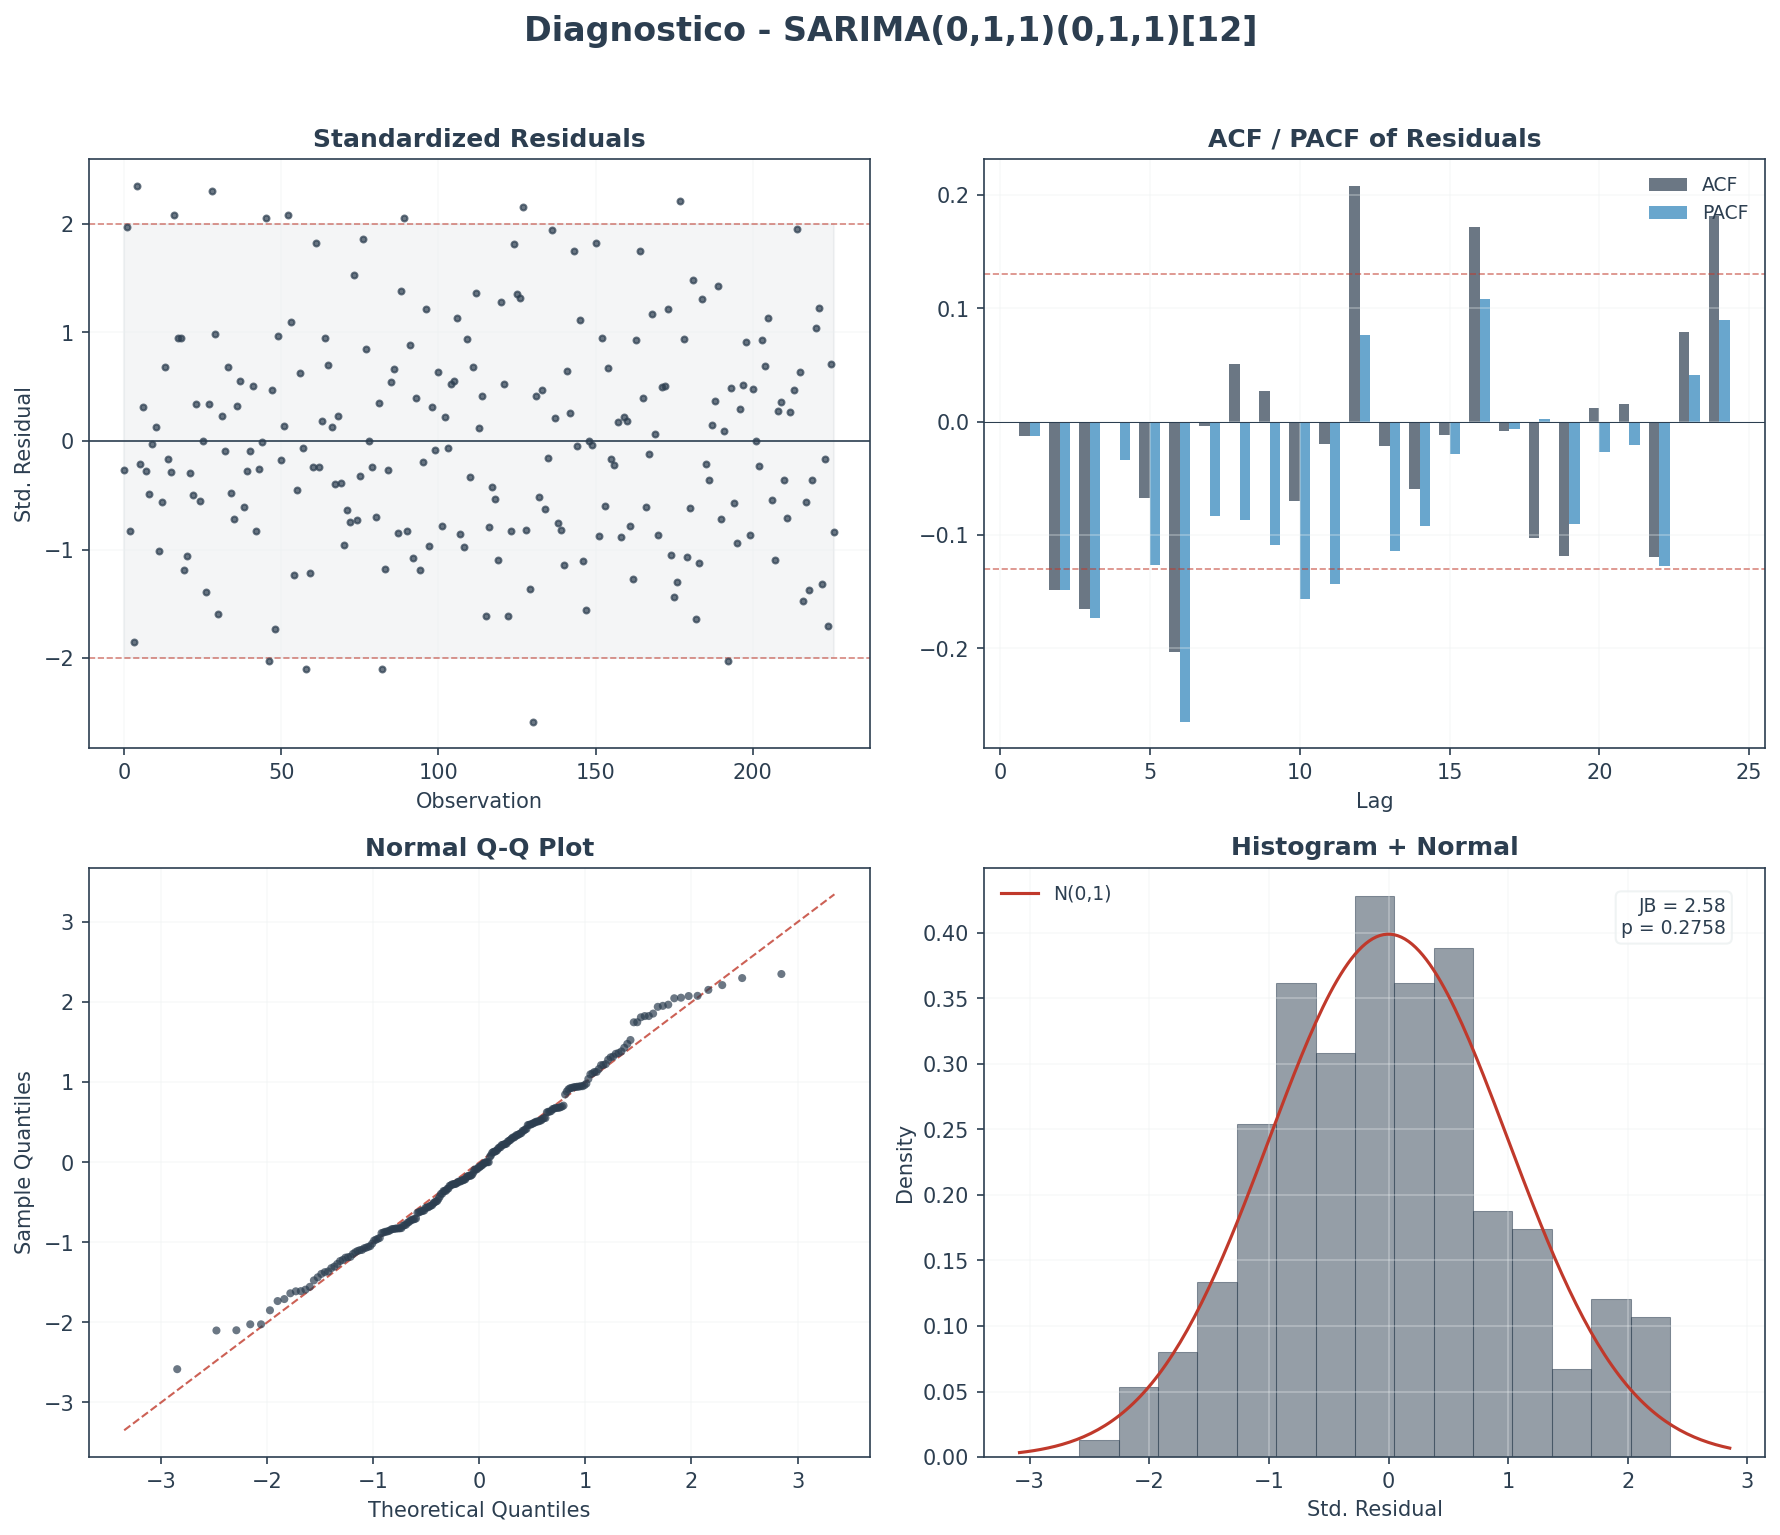

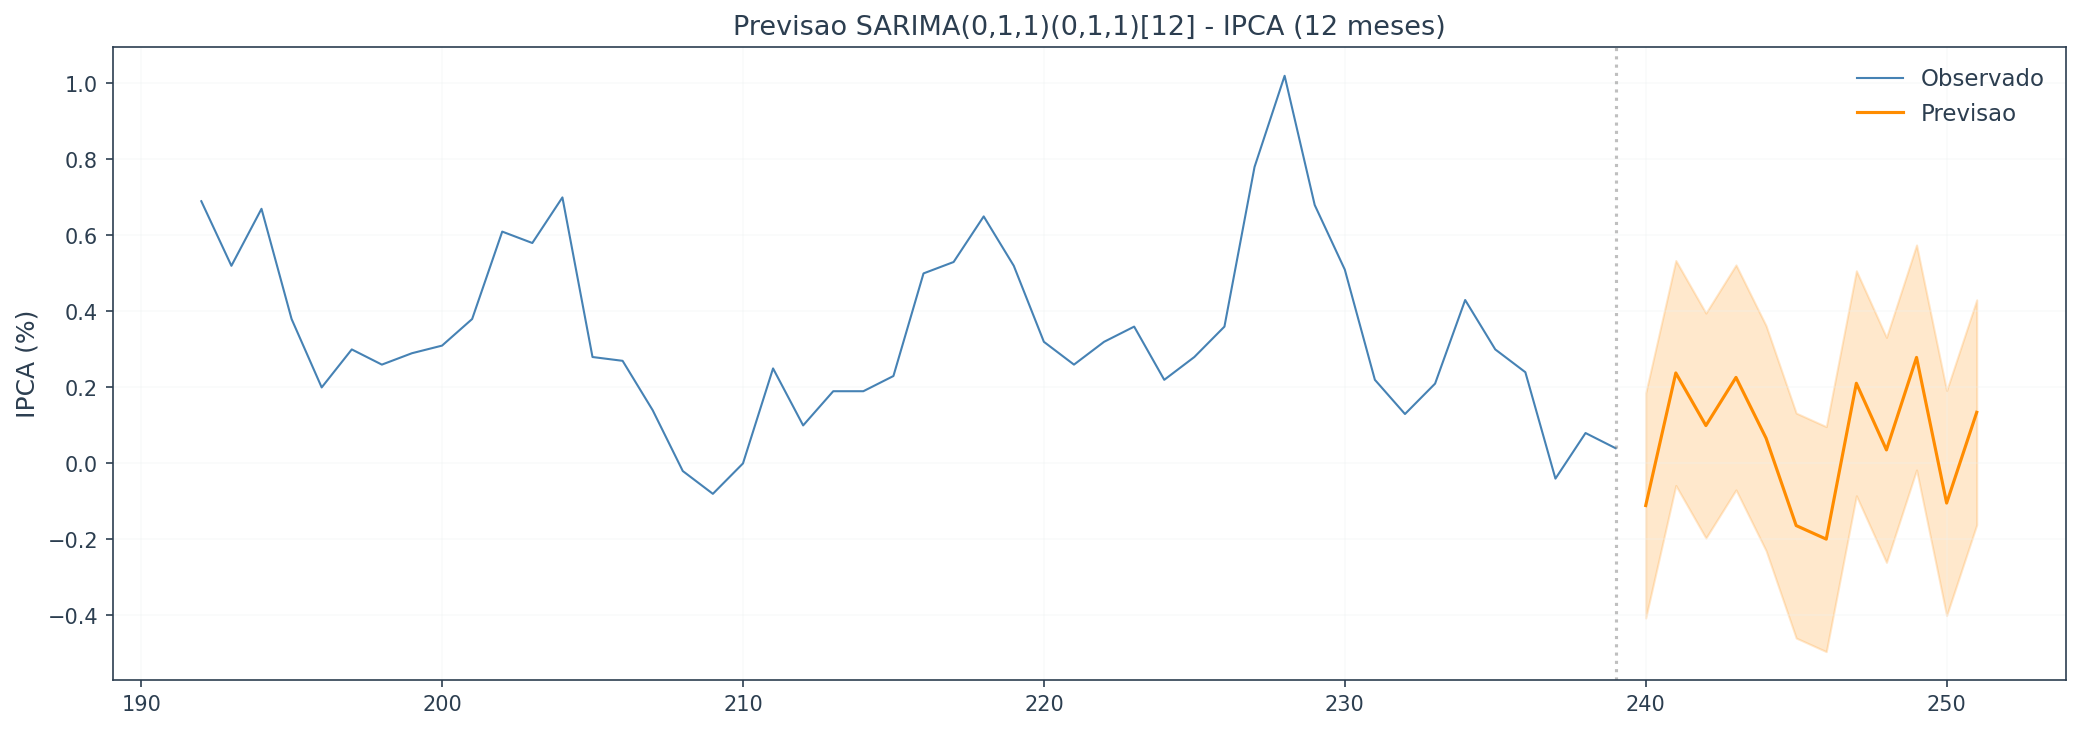

A previsao mostra o padrao sazonal da inflacao brasileira.


In [16]:
# 5. Diagnostico do melhor modelo
res_best_ipca = resultados_ipca[melhor_ipca]
fig = plot_diagnostics(res_best_ipca, lags=24, title=f'Diagnostico - {melhor_ipca}')
plt.show()

# 6. Previsao de 12 meses
fc_ipca_12 = res_best_ipca.forecast(steps=12, alpha=0.05)

fig, ax = plt.subplots(figsize=(14, 5))
n_show = 48
ax.plot(range(len(y_ipca)-n_show, len(y_ipca)), y_ipca[-n_show:], 
        color='steelblue', linewidth=1.0, label='Observado')
x_fc = np.arange(len(y_ipca), len(y_ipca) + 12)
ax.plot(x_fc, fc_ipca_12['forecast'], color='darkorange', linewidth=1.5, label='Previsao')
ax.fill_between(x_fc, fc_ipca_12['lower'], fc_ipca_12['upper'], alpha=0.2, color='darkorange')
ax.axvline(len(y_ipca)-1, color='gray', linestyle=':', alpha=0.5)
ax.set_title(f'Previsao {melhor_ipca} - IPCA (12 meses)', fontsize=13)
ax.set_ylabel('IPCA (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('A previsao mostra o padrao sazonal da inflacao brasileira.')

## Exercicio 2: Efeito da Transformacao Log - SOLUCAO

**Objetivo:** Comparar o SARIMA(0,1,1)(0,1,1)[12] ajustado com e sem transformacao log nos dados airline.

Avaliar:
- AIC/BIC (nota: nao sao diretamente comparaveis entre escalas diferentes)
- Ljung-Box nos residuos
- Homocedasticidade visual dos residuos

In [17]:
# Exercicio 2 - SOLUCAO COMPLETA
# SARIMA(0,1,1)(0,1,1)[12] SEM log
sarima_nolog = ARIMA(order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
res_nolog = sarima_nolog.fit(y)  # y original (sem log)

# SARIMA(0,1,1)(0,1,1)[12] COM log (ja ajustado acima)
res_log = res_sarima  # y_log

print('=== Comparacao dos diagnosticos ===')
print(f'{"Metrica":<25} {"Sem Log":>12} {"Com Log":>12}')
print('-' * 50)
print(f'{"AIC":<25} {res_nolog.aic:>12.2f} {res_log.aic:>12.2f}')
print(f'{"BIC":<25} {res_nolog.bic:>12.2f} {res_log.bic:>12.2f}')

# Ljung-Box comparacao
lb_nolog = ljung_box_test(res_nolog.residuals, lags=24, model_df=2)
lb_log = ljung_box_test(res_log.residuals, lags=24, model_df=2)
print(f'{"Ljung-Box(24) p-valor":<25} {lb_nolog.pvalue:>12.4f} {lb_log.pvalue:>12.4f}')

=== Comparacao dos diagnosticos ===
Metrica                        Sem Log      Com Log
--------------------------------------------------
AIC                            1021.00      -483.39
BIC                            1029.63      -474.77
Ljung-Box(24) p-valor           0.0084       0.4311


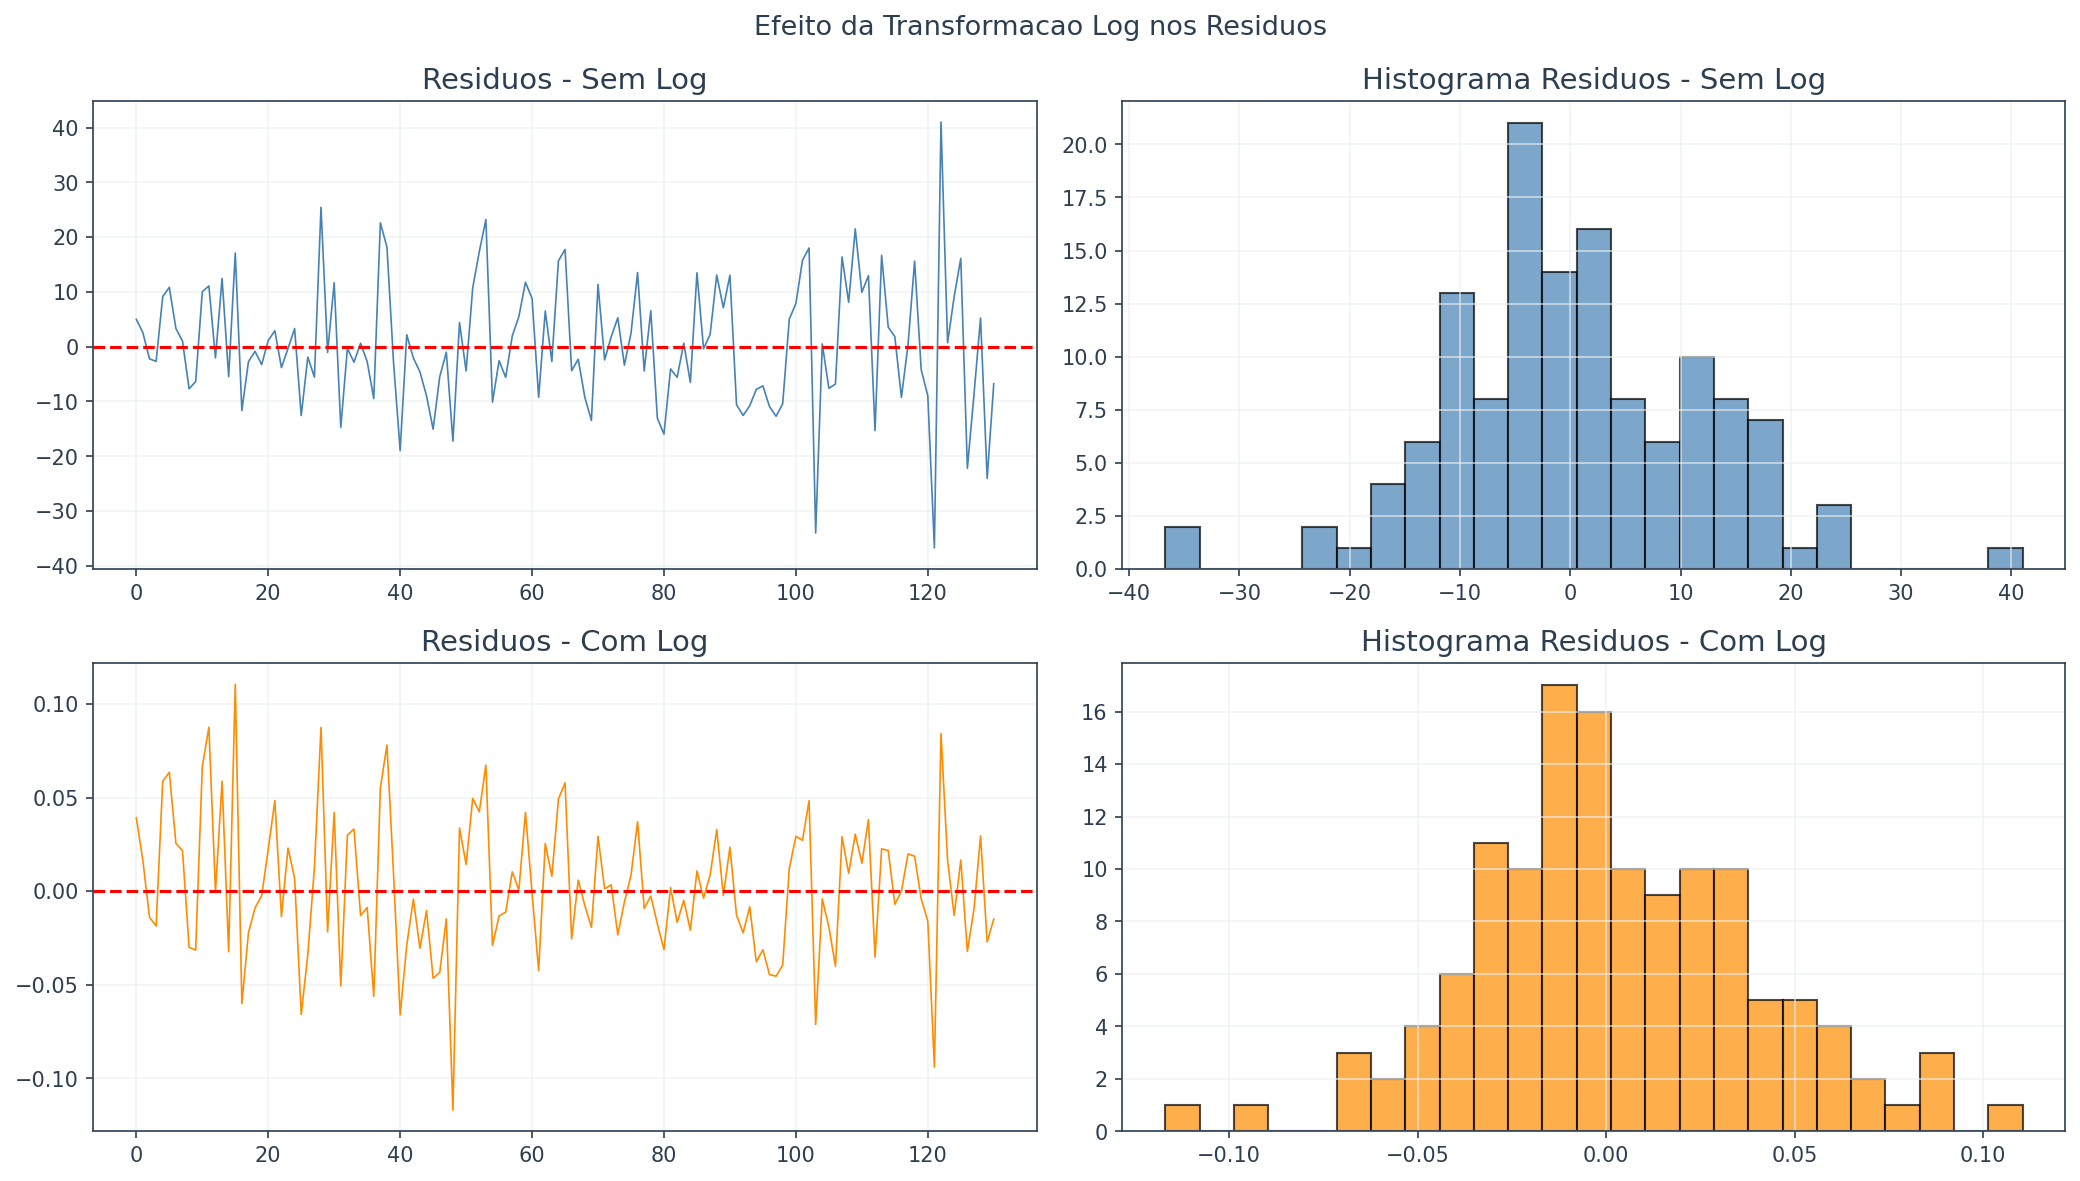

Conclusao: A transformacao log produz residuos mais homoscedasticos.
Sem log: variancia dos residuos cresce com o nivel da serie (heterocedasticidade).
Com log: variancia dos residuos e mais constante ao longo do tempo.


In [18]:
# Residuos: homocedasticidade
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Sem log
axes[0, 0].plot(res_nolog.residuals, color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Residuos - Sem Log')
axes[0, 0].axhline(0, color='red', linestyle='--')

axes[0, 1].hist(res_nolog.residuals, bins=25, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Histograma Residuos - Sem Log')

# Com log
axes[1, 0].plot(res_log.residuals, color='darkorange', linewidth=0.8)
axes[1, 0].set_title('Residuos - Com Log')
axes[1, 0].axhline(0, color='red', linestyle='--')

axes[1, 1].hist(res_log.residuals, bins=25, color='darkorange', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Histograma Residuos - Com Log')

plt.suptitle('Efeito da Transformacao Log nos Residuos', fontsize=13)
plt.tight_layout()
plt.show()

print('Conclusao: A transformacao log produz residuos mais homoscedasticos.')
print('Sem log: variancia dos residuos cresce com o nivel da serie (heterocedasticidade).')
print('Com log: variancia dos residuos e mais constante ao longo do tempo.')

In [19]:
# Resumo quantitativo dos modelos
print('=' * 60)
print('RESUMO: Comparacao SARIMA - Airline Passengers (log)')
print('=' * 60)
for nome, res in resultados.items():
    fc = res.forecast(steps=12, alpha=0.05)
    rmse_insample = np.sqrt(np.mean(res.residuals**2))
    print(f'\n{nome}:')
    print(f'  AIC={res.aic:.2f}  BIC={res.bic:.2f}  LogLik={res.loglike:.2f}')
    print(f'  RMSE in-sample={rmse_insample:.6f}')
    print(f'  Forecast mean (12 steps)={np.mean(fc["forecast"]):.4f}')


RESUMO: Comparacao SARIMA - Airline Passengers (log)

ARIMA(1,1,1):
  AIC=-238.60  BIC=-229.72  LogLik=122.30
  RMSE in-sample=0.102601
  Forecast mean (12 steps)=0.0039

SARIMA(0,1,1)(0,1,1)[12]:
  AIC=-483.39  BIC=-474.77  LogLik=244.70
  RMSE in-sample=0.037282
  Forecast mean (12 steps)=0.0029

SARIMA(1,1,0)(0,1,1)[12]:
  AIC=-481.48  BIC=-472.86  LogLik=243.74
  RMSE in-sample=0.037456
  Forecast mean (12 steps)=0.0025

SARIMA(1,1,1)(0,1,1)[12]:
  AIC=-481.89  BIC=-470.39  LogLik=244.95
  RMSE in-sample=0.037283
  Forecast mean (12 steps)=0.0031


## Salvando Resultados

In [20]:
# Salvar resultados em outputs/sarima_results.json
sarima_results = {}

# Modelos no airline
for nome, res in [('ARIMA(1,1,1)_sem_sazonal', res_arima if 'res_arima' in dir() else None),
                   ('SARIMA(0,1,1)(0,1,1)[12]_log', res_sarima)]:
    if res is None:
        continue
    coefs = {}
    for pname, pval in zip(res.param_names, res.params):
        coefs[pname] = round(float(pval), 6)
    sarima_results[nome] = {
        'coefficients': coefs,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'loglike': round(float(res.loglike), 4),
        'dataset': 'airline'
    }

# Actually build it properly with all models
sarima_results = {}

# Airline models
arima_puro = ARIMA(order=(1, 1, 1))
res_arima_puro = arima_puro.fit(y_log)

for label, res in [
    ('airline_ARIMA(1,1,1)', res_arima_puro),
    ('airline_SARIMA(0,1,1)(0,1,1)[12]', res_sarima),
]:
    coefs = {}
    for pname, pval in zip(res.param_names, res.params):
        coefs[pname] = round(float(pval), 6)
    sarima_results[label] = {
        'coefficients': coefs,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'loglike': round(float(res.loglike), 4)
    }

# IPCA models
for nome, res in resultados_ipca.items():
    coefs = {}
    for pname, pval in zip(res.param_names, res.params):
        coefs[pname] = round(float(pval), 6)
    sarima_results[f'ipca_{nome}'] = {
        'coefficients': coefs,
        'aic': round(float(res.aic), 4),
        'bic': round(float(res.bic), 4),
        'loglike': round(float(res.loglike), 4)
    }

# Log vs no-log comparison
sarima_results['airline_nolog_SARIMA(0,1,1)(0,1,1)[12]'] = {
    'aic': round(float(res_nolog.aic), 4),
    'bic': round(float(res_nolog.bic), 4),
    'note': 'Sem transformacao log - heterocedasticidade nos residuos'
}

# Forecasts from best IPCA model
fc_ipca = res_best_ipca.forecast(steps=12, alpha=0.05)
sarima_results['ipca_forecast_12m'] = {
    'model': melhor_ipca,
    'forecast': [round(float(v), 6) for v in fc_ipca['forecast']],
    'lower_95': [round(float(v), 6) for v in fc_ipca['lower']],
    'upper_95': [round(float(v), 6) for v in fc_ipca['upper']]
}

output_path = os.path.join(OUTPUT_DIR, 'sarima_results.json')
with open(output_path, 'w') as f:
    json.dump(sarima_results, f, indent=2)

print(f'Resultados SARIMA salvos em: {output_path}')
print(f'Total de entradas: {len(sarima_results)}')
for k in sarima_results:
    print(f'  - {k}')

Resultados SARIMA salvos em: /home/guhaase/projetos/chronobox/examples/arima/outputs/sarima_results.json
Total de entradas: 9
  - airline_ARIMA(1,1,1)
  - airline_SARIMA(0,1,1)(0,1,1)[12]
  - ipca_SARIMA(1,1,0)(1,1,0)[12]
  - ipca_SARIMA(0,1,1)(0,1,1)[12]
  - ipca_SARIMA(1,1,1)(0,1,1)[12]
  - ipca_SARIMA(1,1,0)(0,1,1)[12]
  - ipca_SARIMA(0,1,1)(1,1,1)[12]
  - airline_nolog_SARIMA(0,1,1)(0,1,1)[12]
  - ipca_forecast_12m


/home/guhaase/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


## Conclusao

Neste notebook solution:

1. **Exercicio 1**: Ajustamos 5 modelos SARIMA no IPCA brasileiro, selecionando o melhor por AIC.
2. **Exercicio 2**: Demonstramos que a transformacao log melhora homocedasticidade dos residuos no airline.

**Outputs salvos:**
- `outputs/sarima_results.json`: coeficientes, metricas e previsoes de todos os modelos SARIMA